In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import importlib

import os
os.chdir("..")

import models.NN_layers as NN_layers
importlib.reload(NN_layers)
from models.NN_layers import *

import models.Model as Model
importlib.reload(Model)
from models.Model import *

import torch 
import torch.nn as nn
import torch.nn.functional  as F

from torch import Tensor
from torchvision import transforms

import pandas as pd
import PIL.Image as Image

import kagglehub
path = kagglehub.dataset_download("zalando-research/fashionmnist")

c:\Users\katin\OneDrive - Danmarks Tekniske Universitet\6 semester\Fagprojekt\Fagprojekt---Group-Equivariance\fag_projekt\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
model = NaiveGE_CNN(kernel_size = 5, l = 2, in_features = 1, img_size = 28, n_conv_layers = 4, conv_pr_pool = 1, channels = 32, n_classes= 10, bias= True)

### Load billeder

In [2]:
df = pd.read_csv(path + '/fashion-mnist_train.csv') #læs billeder

In [3]:
def format_img(num_images = 1000):
    df_train = df[:num_images]
    img_rows = df_train.iloc[:, 1:].to_numpy() #converts to numpy array (outer dim is pictures)
    img_square = img_rows.reshape(-1, 28,28).astype(np.uint8) # reshape inner dim to be a pictur HxW
    images = torch.tensor(img_square, dtype=torch.complex64).unsqueeze_(1) / 255.0  # make into tensor and scale pixel values to be in range [0,1] instead of [0,255]
    return images

In [4]:
images = format_img(num_images=3)

### Roter billeder til 8 vinkler

In [40]:
def rotate_batch(images, angles_deg):
    images = images.real.to(torch.float64)
    # images: [B, C, H, W]
    B, C, H, W = images.shape
    device = images.device

    out = []

    for angle in angles_deg:
        theta = np.radians(angle)

        # rotation matrix (inverse mapping for grid_sample)
        rot = torch.tensor([
            [np.cos(theta), -np.sin(theta), 0],
            [np.sin(theta),  np.cos(theta), 0]
        ], device=device).unsqueeze(0).repeat(B, 1, 1)

        grid = F.affine_grid(rot, images.size(), align_corners=False)
        rotated = F.grid_sample(images, grid, align_corners=False)
        out.append(rotated)
    return torch.stack(out, dim=1).to(torch.complex64)  # [B, 8, C, H, W]

In [41]:
angles = [i * 45 for i in range(8)]

rotated_images = rotate_batch(images, angles)
print(rotated_images.shape)

torch.Size([3, 8, 1, 28, 28])


### Compute output from model

In [46]:
import torchvision.transforms.functional as TF

# ---------- helpers ----------

def rot90_any(x, k):
    """Eksakt rotation med k*90 grader paa pixelgrid. Virker for baade real og complex."""
    return torch.rot90(x, k, dims=(-2, -1))

def rotate_any(x, angle):
    """Interpoleret rotation (vilkaarlig vinkel). Complex roteres som real+imag hver for sig."""
    if x.is_complex():
        return torch.complex(TF.rotate(x.real, angle), TF.rotate(x.imag, angle))
    return TF.rotate(x, angle)

def rel_err(a, b):
    """Gennemsnitlig absolut forskel, normaliseret med signalets stoerrelse."""
    return (a - b).abs().mean().item() / (a.abs().mean().item() + 1e-12)

class ComplexAdaptiveAvgPool2d(nn.Module):
    """nn.AdaptiveAvgPool2d understoetter ikke complex tensors.
    Pooling er lineaer, saa vi pooler real- og imaginaerdel hver for sig (samme resultat)."""
    def __init__(self, output_size):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(output_size)
    def forward(self, x):
        if x.is_complex():
            return torch.complex(self.pool(x.real), self.pool(x.imag))
        return self.pool(x)

# ---------- byg test-pipeline ----------
# Spejler NaiveGE_CNN(n_conv_layers=2, conv_pr_pool=1, channels=8), men med
# complex-sikker pooling. NaiveGE_CNN selv crasher pt. paa nn.AdaptiveAvgPool2d,
# fordi den ikke kan tage complex input.
kernel_size, l, bias = 5, 2, True
len_basis = 2 * l + 1
ls = [8, 16, 32]

test_model = nn.Sequential(
    LiftingLayer(1, ls[0], kernel_size=kernel_size, l=l, bias=bias),
    ConvLayer(ls[0] * len_basis, ls[1], kernel_size=kernel_size, l=l, bias=bias),
    NormNonlinearity(ls[1] * len_basis),
    ComplexAdaptiveAvgPool2d((14, 14)),
    ConvLayer(ls[1] * len_basis, ls[2], kernel_size=kernel_size, l=l, bias=bias),
    NormNonlinearity(ls[2] * len_basis),
    ComplexAdaptiveAvgPool2d((7, 7)),
    ProjectionLayer(ls[2], 10, l=l, bias=bias),
)
test_model.eval()
print(test_model)

Sequential(
  (0): LiftingLayer(
    (mlps): ModuleList(
      (0-39): 40 x MLP_Radius(
        (layer): Sequential(
          (0): Linear(in_features=1, out_features=4, bias=True)
          (1): ReLU()
          (2): Linear(in_features=4, out_features=1, bias=True)
        )
      )
    )
  )
  (1): ConvLayer()
  (2): NormNonlinearity()
  (3): ComplexAdaptiveAvgPool2d(
    (pool): AdaptiveAvgPool2d(output_size=(14, 14))
  )
  (4): ConvLayer()
  (5): NormNonlinearity()
  (6): ComplexAdaptiveAvgPool2d(
    (pool): AdaptiveAvgPool2d(output_size=(7, 7))
  )
  (7): ProjectionLayer(
    (lin): Linear(in_features=32, out_features=10, bias=True)
  )
)


1) Fuld pipeline, invarians af logits (model(Rx) vs model(x)):
    90 grader (eksakt rot):   rel. fejl = 2.02e-03
   180 grader (eksakt rot):   rel. fejl = 2.11e-03
   270 grader (eksakt rot):   rel. fejl = 1.57e-03
    45 grader (interpoleret): rel. fejl = 1.07e-02
   135 grader (interpoleret): rel. fejl = 9.77e-03

2) Feature maps, |Phi(Rx)| vs R|Phi(x)| ved 90 grader:
   LiftingLayer  rel. fejl = 6.75e-02
   Lift + Conv   rel. fejl = 8.97e-02

3) LiftingLayer, fuldt tjek inkl. fase:
   konvention e^(+i m theta): rel. fejl = 5.62e-01
   konvention e^(-i m theta): rel. fejl = 1.64e-01


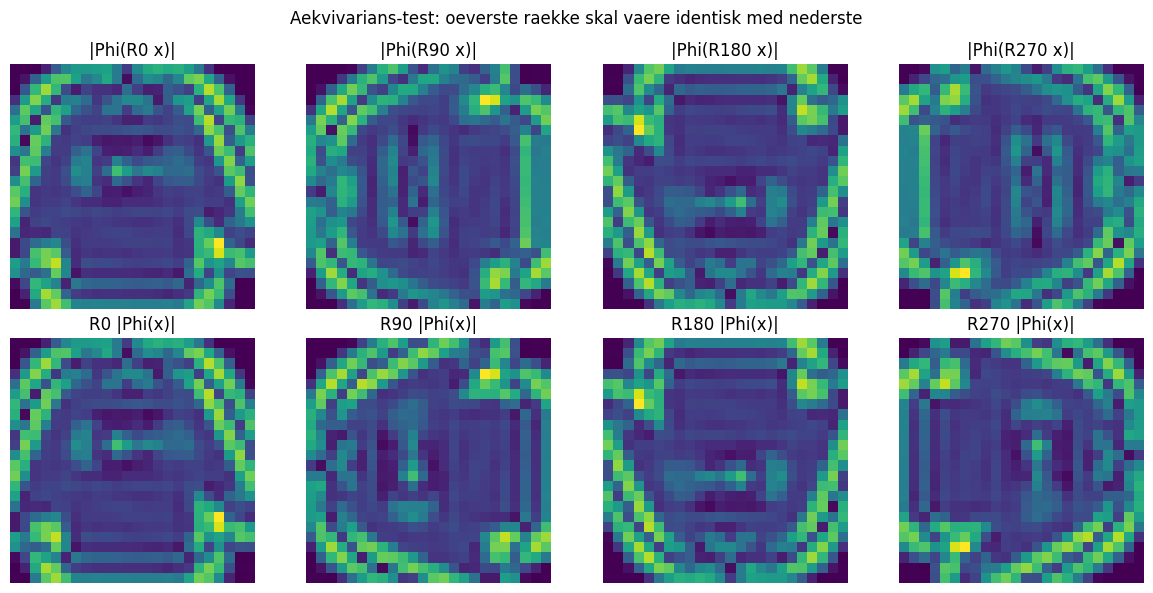

In [43]:
test_image = images[0:1].to(torch.complex64)

# ============================================================
# 1) INVARIANS af hele pipelinen: logits skal vaere ens for roteret input.
#    90/180/270 grader er EKSAKTE paa pixelgrid, saa her skal fejlen vaere
#    paa float32-stoejniveau (~1e-6). Stoerre fejl = aekvivariansfejl i et lag.
#    45/135 grader kraever interpolation, saa der er en stoerre fejl ventet.
# ============================================================
with torch.no_grad():
    logits_0 = test_model(test_image)
    print("1) Fuld pipeline, invarians af logits (model(Rx) vs model(x)):")
    for angle in [90, 180, 270]:
        logits_r = test_model(rot90_any(test_image, angle // 90))
        print(f"   {angle:3d} grader (eksakt rot):   rel. fejl = {rel_err(logits_0, logits_r):.2e}")
    for angle in [45, 135]:
        logits_r = test_model(rotate_any(test_image, angle))
        print(f"   {angle:3d} grader (interpoleret): rel. fejl = {rel_err(logits_0, logits_r):.2e}")

# ============================================================
# 2) AEKVIVARIANS af feature maps, lag for lag.
#    En kanal med frekvens m faar en fase e^(i m theta) naar input roteres,
#    saa man kan IKKE sammenligne de komplekse vaerdier direkte efter spatial
#    rotation. Magnituden |f| er fasefri: |Phi(Rx)| = R|Phi(x)| skal gaelde
#    EKSAKT ved 90 grader, uanset fasekonvention.
# ============================================================
lift = test_model[0]
conv = test_model[1]

with torch.no_grad():
    x_rot = rot90_any(test_image, 1)
    print("\n2) Feature maps, |Phi(Rx)| vs R|Phi(x)| ved 90 grader:")
    for name, f in [("LiftingLayer", lambda z: lift(z)),
                    ("Lift + Conv", lambda z: conv(lift(z)))]:
        out = f(test_image)
        out_rot = f(x_rot)
        err = rel_err(out_rot.abs(), rot90_any(out.abs(), 1))
        print(f"   {name:13s} rel. fejl = {err:.2e}")

# ============================================================
# 3) Fuldt steerable-tjek inkl. fase for LiftingLayer:
#    Phi(Rx) = e^(+-i m theta) * R Phi(x) pr. kanal med frekvens m.
#    Vi tester begge fortegnskonventioner; den rigtige skal give ~1e-6.
# ============================================================
with torch.no_grad():
    theta = np.pi / 2
    out = lift(test_image)
    out_rot = lift(rot90_any(test_image, 1))
    m = (torch.arange(out.shape[1]) % len_basis - l).to(torch.float32)
    print("\n3) LiftingLayer, fuldt tjek inkl. fase:")
    for sign in (+1, -1):
        phase = torch.exp(1j * sign * m * theta).to(out.dtype)
        pred = phase[None, :, None, None] * rot90_any(out, 1)
        s = '+' if sign > 0 else '-'
        print(f"   konvention e^({s}i m theta): rel. fejl = {rel_err(out_rot, pred):.2e}")

# ============================================================
# 4) Visuel sammenligning: |Phi(Rx)| (oeverst) vs R|Phi(x)| (nederst)
#    for kanal 0 af LiftingLayer. Raekkerne skal vaere identiske.
# ============================================================
plot_angles = [0, 90, 180, 270]
with torch.no_grad():
    out = lift(test_image)
    fig, axes = plt.subplots(2, len(plot_angles), figsize=(3 * len(plot_angles), 6))
    for j, angle in enumerate(plot_angles):
        k = angle // 90
        img_top = lift(rot90_any(test_image, k))[0, 0].abs().numpy()
        img_bot = rot90_any(out, k)[0, 0].abs().numpy()
        axes[0, j].imshow(img_top)
        axes[0, j].set_title(f'|Phi(R{angle} x)|')
        axes[0, j].axis('off')
        axes[1, j].imshow(img_bot)
        axes[1, j].set_title(f'R{angle} |Phi(x)|')
        axes[1, j].axis('off')
    plt.suptitle('Aekvivarians-test: oeverste raekke skal vaere identisk med nederste')
    plt.tight_layout()
    plt.show()